### Xgboost from PCA v3 dataset 

In [127]:
import pandas as pd
from sklearn.model_selection import train_test_split, GroupShuffleSplit, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import json
import os
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import random as rd
from datetime import datetime

In [128]:
def log_experiment(params, accuracy, cm_normalized, labels, filepath="experiment_logs.jsonl", mode="jsonl"):
    """
    Logs hyperparameter tuning runs to either JSON Lines or CSV.
    
    cm_normalized: numpy array from confusion_matrix(y_test, y_pred, normalize='true')
    labels: list/array of class names from le.classes_
    """
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    
    if mode == "jsonl":
        # Create dictionary representation of the confusion matrix (actual -> predicted -> %)
        cm_dict = {
            actual: {pred: round(float(cm_normalized[i, j] * 100), 2) 
                     for j, pred in enumerate(labels)}
            for i, actual in enumerate(labels)
        }
        
        entry = {
            "timestamp": timestamp,
            "accuracy": round(float(accuracy), 4),
            "hyperparameters": params,
            "confusion_matrix_pct": cm_dict
        }
        
        with open(filepath, "a") as f:
            f.write(json.dumps(entry) + "\n")
        print(f"Logged run to {filepath} (JSONL)")

    elif mode == "csv":
        # Flatten parameters and confusion matrix entries into a single dictionary row
        row = {
            "timestamp": timestamp,
            "accuracy": round(float(accuracy), 4),
            **{f"param_{k}": v for k, v in params.items()}
        }
        
        # Flatten confusion matrix percentages: cm_<actual>_<predicted>
        for i, actual in enumerate(labels):
            for j, pred in enumerate(labels):
                col_name = f"cm_{actual}_{pred}"
                row[col_name] = round(float(cm_normalized[i, j] * 100), 2)
        
        df_row = pd.DataFrame([row])
        file_exists = os.path.isfile(filepath)
        df_row.to_csv(filepath, mode="a", index=False, header=not file_exists)
        print(f"Logged run to {filepath} (CSV)")

In [ ]:
param = {
    'learning_rate': 0.01,
    'max_depth': 1,
    'n_estimators': 2,
    'num_round': 50,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 2
}

In [130]:
df_pca = pd.read_csv('../dataset/full.v3_2026-09-24_22:33:20.csv')
df_pca.head()

,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-max()-Z,tBodyAcc-min()-Z,tBodyAcc-energy()-Y,tBodyAcc-energy()-Z,tBodyAcc-entropy()-X,tBodyAcc-entropy()-Y,tBodyAcc-entropy()-Z,...,fBodyBodyGyroMag-skewness(),fBodyBodyGyroJerkMag-maxInds,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)",Activity,subject
0,-0.995279,-0.983111,-0.913526,-0.744413,0.814263,-0.999863,-0.994612,-0.407747,-0.679338,-0.602122,...,0.586156,-1.000000,-0.074323,-0.298676,-0.112754,0.030400,-0.464761,-0.018446,STANDING,1
1,-0.998245,-0.975300,-0.960322,-0.818409,0.822637,-0.999788,-0.998405,-0.714892,-0.500930,-0.570979,...,-0.336310,-1.000000,0.158075,-0.595051,0.053477,-0.007435,-0.732626,0.703511,STANDING,1
2,-0.995380,-0.967187,-0.978944,-0.818409,0.839344,-0.999660,-0.999470,-0.592235,-0.485821,-0.570979,...,-0.535352,-0.555556,0.414503,-0.390748,-0.118559,0.177899,0.100699,0.808529,STANDING,1
3,-0.996091,-0.983403,-0.990675,-0.829711,0.837869,-0.999736,-0.999504,-0.627446,-0.850930,-0.911872,...,-0.230091,-0.936508,0.404573,-0.117290,-0.036788,-0.012892,0.640011,-0.485366,STANDING,1
4,-0.998139,-0.980817,-0.990482,-0.824705,0.837869,-0.999856,-0.999757,-0.786553,-0.559477,-0.761434,...,-0.510282,-0.936508,0.087753,-0.351471,0.123320,0.122542,0.693578,-0.615971,STANDING,1


In [131]:
X = df_pca.drop(["Activity", "subject"], axis=1) # Predictors (69 components)
y = df_pca["Activity"]                        # Target variable
le = LabelEncoder()
y = le.fit_transform(y)
y = pd.DataFrame(y)
groups = df_pca["subject"]

In [132]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=69)

# Get indices for train and test sets based on Subject groups
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]

train_subjects = sorted(groups_train.unique())
test_subjects = sorted(groups_test.unique())

print("Subjects in training data:")
print(train_subjects)

print("\nSubjects in test data:")
print(test_subjects)

print("\nNumber of training subjects:", len(train_subjects))
print("Number of test subjects:", len(test_subjects))

overlap = set(train_subjects) & set(test_subjects)
print("\nOverlapping subjects:", overlap)

Subjects in training data:
[np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(17), np.int64(18), np.int64(19), np.int64(21), np.int64(23), np.int64(24), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]

Subjects in test data:
[np.int64(3), np.int64(9), np.int64(14), np.int64(15), np.int64(16), np.int64(20), np.int64(22), np.int64(25), np.int64(26)]

Number of training subjects: 21
Number of test subjects: 9

Overlapping subjects: set()


In [133]:
model = xgb.XGBClassifier(**param)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)



y_decoded = le.inverse_transform(y_test)
y_pred_decoded = le.inverse_transform(y_pred)
y_decoded = pd.DataFrame(y_decoded)
y_pred_decoded = pd.DataFrame(y_pred_decoded)

print("--- Classification Report (Unseen Subjects) ---")
print(classification_report(y_decoded, y_pred_decoded))

--- Classification Report (Unseen Subjects) ---
                    precision    recall  f1-score   support

            LAYING       0.26      1.00      0.41       594
           SITTING       0.00      0.00      0.00       555
          STANDING       0.55      0.77      0.64       581
           WALKING       0.00      0.00      0.00       504
WALKING_DOWNSTAIRS       0.00      0.00      0.00       414
  WALKING_UPSTAIRS       0.00      0.00      0.00       474

          accuracy                           0.33      3122
         macro avg       0.13      0.30      0.18      3122
      weighted avg       0.15      0.33      0.20      3122



/Users/jonaskarlsen/Documents/git/haml-et/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:19:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "num_round" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/jonaskarlsen/Documents/git/haml-et/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:161: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/jonaskarlsen/Documents/git/haml-et/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jonaskarlsen/Documents/git/haml-et/.venv/lib/python3.1

Logged run to ../dataset/experiment_logs.jsonl (JSONL)


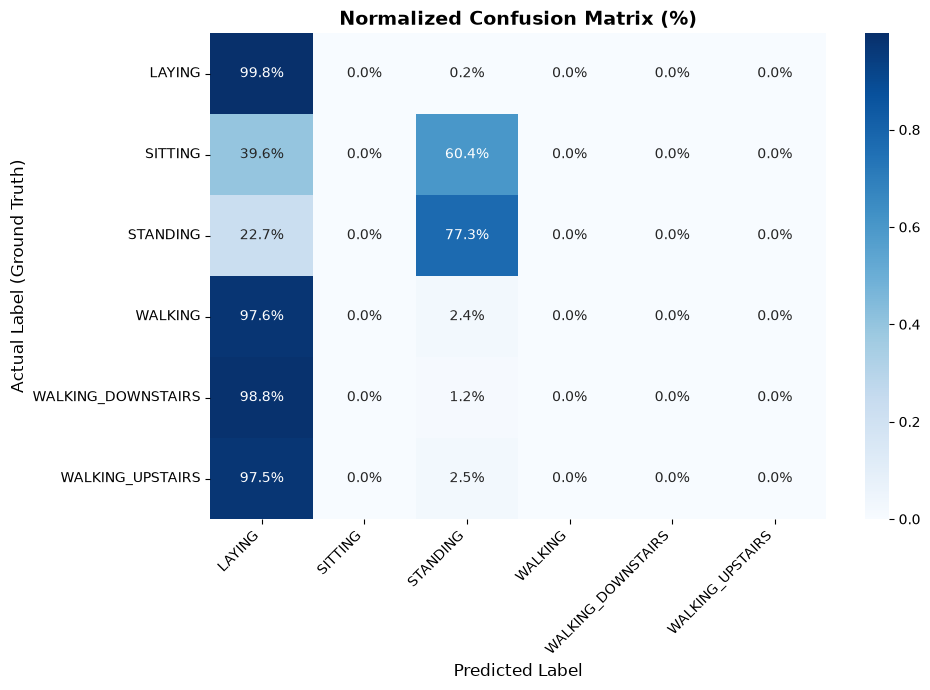

In [134]:
# Compute normalized matrix (percentages along rows)
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')

# Compute metrics
accuracy = accuracy_score(y_test, y_pred)
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')
labels = le.classes_

# Log your experiment (Option 1: JSON Lines)
log_experiment(
    params=param,
    accuracy=accuracy,
    cm_normalized=cm_normalized,
    labels=labels,
    filepath="../dataset/experiment_logs.jsonl",
    mode="jsonl"
)

# Get activity labels in the same order used by LabelEncoder
labels = le.classes_

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_normalized, 
    annot=True, 
    fmt='.1%',              # Format as percentage (e.g., 70.2%)
    cmap='Blues', 
    xticklabels=labels, 
    yticklabels=labels
)

plt.title('Normalized Confusion Matrix (%)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label (Ground Truth)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()